In [19]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import ViTModel
import matplotlib.pyplot as plt
import pandas as pd

IMAGE_DIR = "../data/training/image_2"
MASK_DIR = "../data/training/gt_image_2"

IMG_SIZE = 224
BATCH_SIZE = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def get_mask_name(img_name):
    stem = img_name.replace(".png", "")
    prefix, idx = stem.split("_", 1)
    return f"{prefix}_road_{idx}.png"

class KITTIRoadDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=224):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, get_mask_name(img_name))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0

        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        road = (mask[:, :, 0] > 150) & (mask[:, :, 2] > 150)
        road = road.astype(np.float32)

        img = torch.tensor(img).permute(2, 0, 1)
        road = torch.tensor(road).unsqueeze(0)

        return img, road
    



In [20]:
class ViTSegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")

        hidden_dim = self.vit.config.hidden_size

        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_dim, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        outputs = self.vit(pixel_values=x)

        patch_tokens = outputs.last_hidden_state[:, 1:, :]

        batch_size, num_patches, hidden_dim = patch_tokens.shape
        h = w = int(num_patches ** 0.5)

        features = patch_tokens.permute(0, 2, 1).reshape(batch_size, hidden_dim, h, w)

        logits = self.decoder(features)

        logits = F.interpolate(
            logits,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        return logits

In [21]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * intersection + 1e-6) / (union + 1e-6)


def iou_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + 1e-6) / (union + 1e-6)

In [22]:
dataset = KITTIRoadDataset(IMAGE_DIR, MASK_DIR, IMG_SIZE)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [23]:
model = ViTSegmentationModel().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        logits = model(imgs)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    model.eval()
    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)

            dice_scores.append(dice_score(logits, masks).item())
            iou_scores.append(iou_score(logits, masks).item())

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Dice: {np.mean(dice_scores):.4f} | "
        f"Val IoU: {np.mean(iou_scores):.4f}"
    )


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Loss: 0.2978 | Val Dice: 0.8715 | Val IoU: 0.7786
Epoch 2/3 | Loss: 0.0945 | Val Dice: 0.8982 | Val IoU: 0.8211
Epoch 3/3 | Loss: 0.0671 | Val Dice: 0.8973 | Val IoU: 0.8196


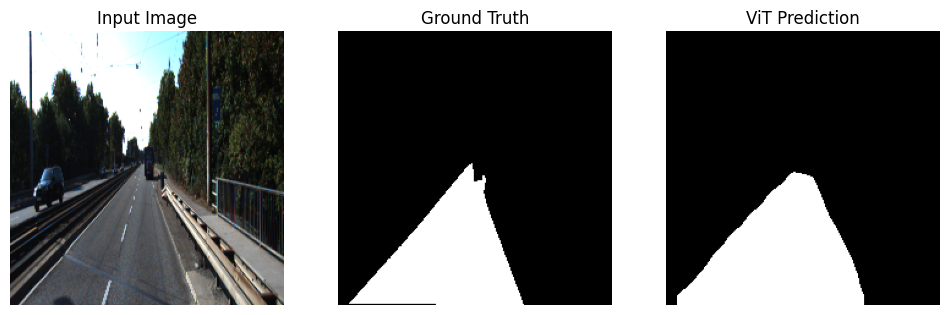

In [24]:
def show_prediction(model, dataset, idx=0):
    model.eval()

    img, mask = dataset[idx]

    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(DEVICE))
        pred = torch.sigmoid(logits).cpu().squeeze().numpy()

    img_np = img.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze().numpy()
    pred_bin = (pred > 0.5).astype(np.float32)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("ViT Prediction")
    plt.axis("off")

    plt.show()


show_prediction(model, val_dataset, idx=0)

In [25]:
thresholds = [0.3, 0.5, 0.7]

results = []

model.eval()

with torch.no_grad():
    for threshold in thresholds:
        dice_list = []
        iou_list = []

        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)

            dice_list.append(dice_score(logits, masks, threshold).item())
            iou_list.append(iou_score(logits, masks, threshold).item())

        results.append({
            "threshold": threshold,
            "dice": np.mean(dice_list),
            "iou": np.mean(iou_list)
        })



results_df = pd.DataFrame(results)

results_df

,threshold,dice,iou
0,0.3,0.875965,0.786173
1,0.5,0.897297,0.819648
2,0.7,0.903235,0.828066
